# **EXPERIMENT-7**  -Seed Dataset

**AIM:**

To construct and evaluate Support Vector Machine (SVM) classifiers using different SVM variants (SVC, NuSVC, LinearSVC) on the Seeds dataset and obtain a generalized classification model through hyperparameter tuning.

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
seeds_data = pd.read_csv('/content/drive/MyDrive/Datasets/Seed_Data.csv')
print("Shape:", seeds_data.shape)
print("\nDuplicated:", seeds_data.duplicated().sum())
print("\nMissing Values:\n", seeds_data.isna().sum())
print("\nFirst 2 Rows:\n")
seeds_data.head(2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (210, 8)

Duplicated: 0

Missing Values:
 A         0
P         0
C         0
LK        0
WK        0
A_Coef    0
LKG       0
target    0
dtype: int64

First 2 Rows:



,A,P,C,LK,WK,A_Coef,LKG,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0


**Remove Duplicates**

In [ ]:
seeds_data = seeds_data.drop_duplicates()
seeds_data.shape

(210, 8)

**Feature-Label Separation**

In [ ]:
X = seeds_data.drop("target", axis=1)
Y = seeds_data["target"]

**Train–Test Split and Feature Scaling**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.2,random_state=42,stratify=Y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("\nFirst 2 Rows of Scaled X_train:\n")
print(pd.DataFrame(X_train[:2], columns=X.columns))


First 2 Rows of Scaled X_train:

          A         P         C        LK        WK    A_Coef       LKG
0 -1.176824 -1.175058 -1.021692 -1.027857 -1.357519  1.431889 -0.824410
1 -0.872984 -1.067146  0.866768 -1.264930 -0.598973 -0.305612 -1.631504


**Model Comparison: SVC with Different Kernels**

We test: Linear,RBF,Polynomial

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]
results = []
for kernel in kernels:
    for C in C_values:
        model = SVC(
            kernel=kernel,
            C=C,
            gamma='scale'
        )
        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)
        results.append([
            kernel,
            C,
            accuracy_score(Y_test, Y_pred),
            f1_score(Y_test, Y_pred, average='weighted')
        ])
results_df = pd.DataFrame(
    results,
    columns=['Kernel','C','Accuracy','Weighted_F1']
)
print(results_df)

   Kernel     C  Accuracy  Weighted_F1
0  linear   0.1  0.904762     0.900000
1  linear   1.0  0.880952     0.873056
2  linear  10.0  0.928571     0.927742
3     rbf   0.1  0.880952     0.876628
4     rbf   1.0  0.904762     0.900000
5     rbf  10.0  0.880952     0.873056
6    poly   0.1  0.714286     0.722222
7    poly   1.0  0.880952     0.882405
8    poly  10.0  0.857143     0.853782


**Best Model Selection**

In [ ]:
best_model = SVC(kernel='linear', C=1)
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

**Decision Boundary Visualization (2D using PCA)**

Since dataset has multiple features, reduce to 2 dimensions using PCA for visualization.


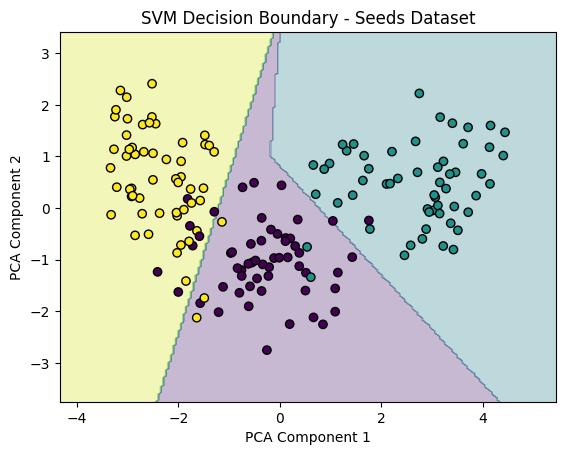

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
model_2d = SVC(kernel='linear', C=1)
model_2d.fit(X_pca, Y_train)
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=Y_train, edgecolor='k')
plt.title("SVM Decision Boundary - Seeds Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

**Support Vectors**

In [ ]:
print("Number of Support Vectors:", model_2d.n_support_)

Number of Support Vectors: [18  8 12]


**Model Evaluation**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

Accuracy: 0.8809523809523809

Confusion Matrix:
 [[ 9  2  3]
 [ 0 14  0]
 [ 0  0 14]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.64      0.78        14
           1       0.88      1.00      0.93        14
           2       0.82      1.00      0.90        14

    accuracy                           0.88        42
   macro avg       0.90      0.88      0.87        42
weighted avg       0.90      0.88      0.87        42

